# Cisco Champions Forecasting League — Demand Forecasting Model
### Phase 1 · FY26 Q2 Forward Forecast

**Author:** Ayush Pandey

**Architecture:** 6-Layer Hierarchical Forecasting Pipeline

**Backtest CWA:** 85.7% on the FY26Q1 backtest, compared with 87.2% for Demand Planners

**Note:** This notebook is presented as an analytical competition project. Some backtest choices, such as expert-weighting based on historical accuracy tables, can be refined further for stricter validation.

---

## Architecture Overview

This model forecasts quarterly unit demand for 30 Cisco products using a **6-layer hierarchical pipeline** that combines statistical time-series methods with expert judgment and external market signals:

```
 ┌─────────────────────────────────────────────────────────────────┐
 │              RAW DEMAND DECOMPOSITION                           │
 │        Total Bookings → Avg Deal + Big Deal Split               │
 └──────────────────────────┬──────────────────────────────────────┘
                            ▼
 ┌─────────────────────────────────────────────────────────────────┐
 │  Layer 1 — BASELINE        │ Rolling mean over last N quarters  │
 │  Layer 2 — SEASONALITY     │ Recency-weighted same-Q index      │
 │  Layer 3 — TREND           │ YoY ratio with clipping            │
 │       ↓ Statistical Forecast = L1 × L2 × L3                     │
 ├─────────────────────────────────────────────────────────────────┤
 │  Layer 4 — EXPERT BLEND    │ Accuracy-weighted DP/Mkt/DS        │
 │       ↓ Consensus = 0.4 × Stat + 0.6 × Expert                   │
 ├─────────────────────────────────────────────────────────────────┤
 │  Layer 5 — EXTERNAL SIGNALS│ SCMS channel + VMS vertical mix    │
 │       ↓ Adjusted = Consensus × External Multiplier              │
 ├─────────────────────────────────────────────────────────────────┤
 │  Layer 6 — CORRECTION      │ PLC-aware adjustments              │
 │       ↓ Final Forecast                                          │
 └─────────────────────────────────────────────────────────────────┘
```

### Data Sources Used
| Sheet | Records | Purpose |
|-------|---------|---------|
| Actual Bookings | 30 products × 12 quarters | Core time-series + expert forecasts + accuracy/bias |
| Big Deal | 30 products × 8 quarters | Big deal vs avg deal decomposition |
| SCMS | 174 rows across 6 channels | Sales channel momentum signals |
| VMS | 422 rows across 15 verticals | Vertical market momentum signals |
| Product Insights | 30 products | PLC stage + product descriptions |

---

## Step 1 — Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Optional: Holt-Winters exponential smoothing for comparison
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HW_AVAILABLE = True
except ImportError:
    HW_AVAILABLE = False

print("Libraries loaded")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}  |  Holt-Winters: {'Yes' if HW_AVAILABLE else 'No'}")

Libraries loaded
   pandas 2.2.2  |  numpy 2.0.2  |  Holt-Winters: Yes


## Step 2 — Data Ingestion

Upload the Excel data pack when prompted. The file contains 6 sheets; we load 4:
- **Actual Bookings**: 30 products x 12 quarters of historical demand + 3 expert forecasts + accuracy/bias tables
- **Big Deal**: Per-product big deal vs average deal split (8 quarters)
- **SCMS**: Sales channel breakdown (Commercial, Enterprise, Public Sector, SMB, Service Provider, Other)
- **VMS**: Vertical market breakdown (15 verticals including Healthcare, Government, Education, etc.)

In [2]:
# =========================================================================
# DATA LOADING
# Colab file upload -> parse all required sheets into DataFrames.
# We use explicit column mappings to handle the multi-header Excel layout.
# =========================================================================

from google.colab import files
import io

print("Upload:  CFL_External_Data_Pack_Phase1.xlsx")
uploaded = files.upload()
FILE_NAME = list(uploaded.keys())[0]
xl = pd.ExcelFile(io.BytesIO(uploaded[FILE_NAME]))

print(f"\nLoaded: {FILE_NAME}")
print(f"   Sheets: {xl.sheet_names}")

Upload:  CFL_External_Data_Pack_Phase1.xlsx


Saving CFL_External Data Pack_Phase1.xlsx to CFL_External Data Pack_Phase1.xlsx

Loaded: CFL_External Data Pack_Phase1.xlsx
   Sheets: ['Glossary', 'Masked Product Insights ', 'Data Pack - Actual Bookings', 'Big Deal', 'SCMS', 'VMS']


## Step 3 — Parse Actuals, Expert Forecasts & Historical Accuracy

The "Actual Bookings" sheet has a complex layout:
- **Rows 4-33** (0-indexed 3:33): Product actuals across 12 quarters (FY23Q2 through FY26Q1)
- **Columns 17-19**: Expert forecasts for FY26Q2 from Demand Planners, Marketing, and Data Science
- **Rows 39-68** (0-indexed 38:68): Historical accuracy and bias for each expert team across 3 quarters

In [3]:
# =========================================================================
# PARSE ACTUAL BOOKINGS
# The Excel layout uses merged headers. We extract by position:
#   Col 0  = Cost Rank (1-30)
#   Col 1  = Product Name
#   Col 2  = Product Life Cycle (Sustaining / Decline / NPI-Ramp)
#   Col 3-14 = Quarterly actuals FY23Q2 through FY26Q1
#   Col 16-18 = Expert forecasts for FY26Q2 (DP, Marketing, DataScience)
# =========================================================================

QUARTERS = ['FY23Q2', 'FY23Q3', 'FY23Q4',
            'FY24Q1', 'FY24Q2', 'FY24Q3', 'FY24Q4',
            'FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4', 'FY26Q1']

raw = pd.read_excel(xl, sheet_name='Data Pack - Actual Bookings', header=None)

# --- Actuals (30 products x 12 quarters) ---
df = raw.iloc[3:33, [0, 1, 2] + list(range(3, 15))].copy()
df.columns = ['Rank', 'Product', 'PLC'] + QUARTERS
df = df.reset_index(drop=True)
for q in QUARTERS:
    df[q] = pd.to_numeric(df[q], errors='coerce')
df['Rank'] = df['Rank'].astype(int)

# --- Expert FY26Q2 forecasts (columns 16, 17, 18 in the raw sheet) ---
exp = raw.iloc[3:33, [16, 17, 18]].copy()
exp.columns = ['DP', 'Marketing', 'DataScience']
for c in exp.columns:
    exp[c] = pd.to_numeric(exp[c], errors='coerce')
df[['DP', 'Marketing', 'DataScience']] = exp.values

# --- Historical accuracy/bias table (rows 38-67, 22 columns) ---
# This table tells us how accurate each expert team was on past quarters,
# which we use to weight their forecasts in Layer 4.
acc = raw.iloc[38:68, :22].copy()
acc.columns = [
    'Rank', 'Product',
    'DP_FY26Q1_Acc',  'DP_FY26Q1_Bias',  'DP_FY25Q4_Acc',  'DP_FY25Q4_Bias',  'DP_FY25Q3_Acc',  'DP_FY25Q3_Bias',
    '_c8',  # separator column
    'Mkt_FY26Q1_Acc', 'Mkt_FY26Q1_Bias', 'Mkt_FY25Q4_Acc', 'Mkt_FY25Q4_Bias', 'Mkt_FY25Q3_Acc', 'Mkt_FY25Q3_Bias',
    '_c15',  # separator column
    'DS_FY26Q1_Acc',  'DS_FY26Q1_Bias',  'DS_FY25Q4_Acc',  'DS_FY25Q4_Bias',  'DS_FY25Q3_Acc',  'DS_FY25Q3_Bias'
]
for c in acc.columns[2:]:
    if not c.startswith('_'):
        acc[c] = pd.to_numeric(acc[c], errors='coerce')
acc['Rank'] = acc['Rank'].astype(int)

# --- Summary ---
print(f"Loaded {len(df)} products x {len(QUARTERS)} quarters of history")
print(f"   PLC distribution: {df['PLC'].value_counts().to_dict()}")
print(f"\n   Sample data (last 4 quarters + expert forecasts):")
print(df[['Rank', 'Product', 'PLC', 'FY25Q3', 'FY25Q4', 'FY26Q1', 'DP', 'Marketing', 'DataScience']].to_string(index=False))

Loaded 30 products x 12 quarters of history
   PLC distribution: {'Sustaining': 23, 'Decline': 6, 'NPI-Ramp': 1}

   Sample data (last 4 quarters + expert forecasts):
 Rank                                                 Product        PLC  FY25Q3  FY25Q4  FY26Q1           DP    Marketing  DataScience
    1                          SWITCH Enterprise 48-Port UPOE Sustaining   14395   18663   13144 15052.101882 14795.306069      17011.0
    2  WIRELESS ACCESS POINT WiFi6E (Internal Antenna) Indoor Sustaining   87843   71494   58318 79000.000000 66274.815710      79114.0
    3                              SWITCH Core 25G/100G Fiber Sustaining    5701    6784    6346  6620.962605  6739.907617       7861.0
    4                          SWITCH Enterprise 24-Port PoE+ Sustaining    9436   10338    8433  9200.438118 10383.999801       9789.0
    5   WIRELESS ACCESS POINT WiFi6 (Internal Antenna) Indoor Sustaining   53710   41524   43188 35588.000000 44460.246720      49532.0
    6            

## Step 4 — Parse Big Deal Data

The Big Deal sheet separates each product demand into two components:
- **Big Deals**: Large, lumpy orders (often one-time or irregular)
- **Avg Deals**: Steady-state recurring demand

This decomposition is critical because big deals add noise to the baseline.
By forecasting avg deals separately (which are more predictable) and adding
a big deal estimate, we get a more stable forecast.

In [4]:
# =========================================================================
# PARSE BIG DEAL SHEET
# Layout: 30 products x 3 sections (Total, Big Deals, Avg Deals)
# Each section has 8 quarters: FY24Q2 through FY26Q1
# We extract the Big Deal columns to decompose demand.
# =========================================================================

big_raw = pd.read_excel(xl, sheet_name='Big Deal', header=None)

# Big Deal columns are at positions 10-17 (8 quarters of big deal units)
BIG_QUARTERS_MAP = {
    'FY24Q2': 10, 'FY24Q3': 11, 'FY24Q4': 12, 'FY25Q1': 13,
    'FY25Q2': 14, 'FY25Q3': 15, 'FY25Q4': 16, 'FY26Q1': 17
}

# Avg Deal columns are at positions 18-25
AVG_QUARTERS_MAP = {
    'FY24Q2': 18, 'FY24Q3': 19, 'FY24Q4': 20, 'FY25Q1': 21,
    'FY25Q2': 22, 'FY25Q3': 23, 'FY25Q4': 24, 'FY26Q1': 25
}

# Build Big Deal DataFrame aligned to product rank
big_df = pd.DataFrame()
big_df['Rank'] = big_raw.iloc[2:32, 0].values.astype(int)
for qname, col_idx in BIG_QUARTERS_MAP.items():
    big_df[f'Big_{qname}'] = pd.to_numeric(big_raw.iloc[2:32, col_idx], errors='coerce').values

# Build Avg Deal DataFrame
avg_df = pd.DataFrame()
avg_df['Rank'] = big_raw.iloc[2:32, 0].values.astype(int)
for qname, col_idx in AVG_QUARTERS_MAP.items():
    avg_df[f'Avg_{qname}'] = pd.to_numeric(big_raw.iloc[2:32, col_idx], errors='coerce').values

big_df = big_df.set_index('Rank')
avg_df = avg_df.set_index('Rank')

# Quick validation: Total ~ Big + Avg for overlapping quarters
print("Big Deal data loaded: 30 products x 8 quarters")
print(f"   Big deal columns: {list(BIG_QUARTERS_MAP.keys())}")
print(f"\n   Sample - Product #1 (SWITCH Enterprise 48-Port UPOE):")
print(f"   {'Quarter':<10} {'Big Deal':>10} {'Avg Deal':>10} {'Total':>10}")
for q in ['FY25Q2', 'FY25Q3', 'FY25Q4', 'FY26Q1']:
    big_val = big_df.loc[1, f'Big_{q}']
    avg_val = avg_df.loc[1, f'Avg_{q}']
    total = df[df['Rank'] == 1][q].values[0]
    print(f"   {q:<10} {big_val:>10,.0f} {avg_val:>10,.0f} {total:>10,.0f}")

Big Deal data loaded: 30 products x 8 quarters
   Big deal columns: ['FY24Q2', 'FY24Q3', 'FY24Q4', 'FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4', 'FY26Q1']

   Sample - Product #1 (SWITCH Enterprise 48-Port UPOE):
   Quarter      Big Deal   Avg Deal      Total
   FY25Q2          1,950     14,306     16,256
   FY25Q3            902     13,493     14,395
   FY25Q4            742     17,921     18,663
   FY26Q1            643     12,501     13,144


## Step 5 — Parse External Signal Data (SCMS + VMS)

These sheets provide the **granular demand decomposition** that powers Layer 5:

**SCMS (Sales Coverage):** How demand distributes across 6 sales channels:
Commercial, Enterprise, Public Sector, SMB, Service Provider, Other

**VMS (Vertical Market):** How demand distributes across ~15 industry verticals:
Education, Government, Healthcare, Financial Services, Manufacturing, Retail, etc.

**Why this matters:** If a product Enterprise channel is trending up +15% YoY
while its overall demand is flat, that signals tailwinds in high-value segments.
We compute per-product momentum multipliers from these trends.

In [5]:
# =========================================================================
# PARSE SCMS (Sales Channel Mix Signals)
# Each product has 6 rows (one per channel) x 13 quarters of data.
# We compute channel-level trends and aggregate into a per-product
# momentum multiplier.
# =========================================================================

SCMS_QUARTERS = ['2023Q1', '2023Q2', '2023Q3', '2023Q4',
                 '2024Q1', '2024Q2', '2024Q3', '2024Q4',
                 '2025Q1', '2025Q2', '2025Q3', '2025Q4', '2026Q1']

scms_raw = pd.read_excel(xl, sheet_name='SCMS', header=None)
scms_data = scms_raw.iloc[3:].copy()
scms_data.columns = ['Rank', 'Product', 'Channel'] + SCMS_QUARTERS
scms_data['Rank'] = pd.to_numeric(scms_data['Rank'], errors='coerce').astype('Int64')
for q in SCMS_QUARTERS:
    scms_data[q] = pd.to_numeric(scms_data[q], errors='coerce')

# Forward-fill Rank for grouped rows
scms_data['Rank'] = scms_data['Rank'].ffill()

print(f"SCMS loaded: {len(scms_data)} rows across {scms_data['Channel'].nunique()} channels")
print(f"   Channels: {sorted(scms_data['Channel'].unique())}")

# =========================================================================
# PARSE VMS (Vertical Market Signals)
# Each product has ~14 vertical rows x 13 quarters.
# Same logic: compute per-vertical trends -> aggregate multiplier.
# =========================================================================

vms_raw = pd.read_excel(xl, sheet_name='VMS', header=None)
vms_data = vms_raw.iloc[3:].copy()
vms_data.columns = ['Rank', 'Product', 'Vertical'] + SCMS_QUARTERS
vms_data['Rank'] = pd.to_numeric(vms_data['Rank'], errors='coerce').astype('Int64')
for q in SCMS_QUARTERS:
    vms_data[q] = pd.to_numeric(vms_data[q], errors='coerce')

vms_data['Rank'] = vms_data['Rank'].ffill()

print(f"VMS loaded: {len(vms_data)} rows across {vms_data['Vertical'].nunique()} verticals")
print(f"   Verticals: {sorted(vms_data['Vertical'].dropna().unique())}")

SCMS loaded: 174 rows across 6 channels
   Channels: ['COMMERCIAL', 'ENTERPRISE', 'OTHER', 'PUBLIC SECTOR', 'SERVICE PROVIDER', 'SMB']
VMS loaded: 422 rows across 15 verticals
   Verticals: ['Education- Public/Private', 'Energy/Utilities', 'Financial Services', 'Government', 'Health Care', 'Hospitality/Hotels & Leisure', 'Manufacturing', 'Media/Entertainment', 'Professional Services', 'Retail', 'Service Provider', 'Technical Services', 'Transportation', 'Unknown', 'Wholesale/Distribution']


## Step 6 — Compute External Signal Multipliers from SCMS + VMS

This is where we derive the Layer 5 multipliers **from actual data** rather than hardcoding them.

**Method:**
1. For each product, compute the **weighted channel/vertical momentum**: the YoY growth rate of each segment, weighted by that segment share of total demand
2. Combine SCMS momentum (60% weight) and VMS momentum (40% weight) into a single multiplier
3. Clip to [0.85, 1.20] to prevent extreme adjustments

**Intuition:** If a product largest sales channel is growing 10% YoY, that is a stronger
signal than if a tiny niche vertical is growing 50%. The weighting ensures we follow the money.

In [6]:
# =========================================================================
# EXTERNAL SIGNAL COMPUTATION
#
# For each product we compute:
#   1. Channel momentum: weighted avg of per-channel YoY growth
#   2. Vertical momentum: weighted avg of per-vertical YoY growth
#   3. Combined multiplier: 0.6 * channel + 0.4 * vertical
#
# Growth is measured as the ratio of recent-2-quarter sum to
# prior-2-quarter sum (a smoothed YoY proxy).
# =========================================================================

def compute_segment_momentum(segment_df, rank, segment_col, recent_qs, prior_qs):
    """
    Compute weighted momentum for a product across its segments.

    Parameters:
        segment_df: DataFrame with per-segment quarterly data
        rank: Product rank to filter on
        segment_col: Column name for segment labels ('Channel' or 'Vertical')
        recent_qs: List of recent quarter column names
        prior_qs: List of prior quarter column names (same length)

    Returns:
        Weighted momentum multiplier (1.0 = no change)
    """
    product_data = segment_df[segment_df['Rank'] == rank]
    if product_data.empty:
        return 1.0

    momenta = []
    weights = []

    for _, row in product_data.iterrows():
        recent_sum = sum(max(0, row.get(q, 0) or 0) for q in recent_qs)
        prior_sum  = sum(max(0, row.get(q, 0) or 0) for q in prior_qs)

        if prior_sum > 10:  # Only trust segments with meaningful volume
            momentum = recent_sum / prior_sum
            momenta.append(momentum)
            weights.append(recent_sum)  # Weight by volume (bigger segments matter more)

    if not momenta:
        return 1.0

    total_weight = sum(weights)
    if total_weight == 0:
        return 1.0

    weighted_momentum = sum(m * w for m, w in zip(momenta, weights)) / total_weight
    return weighted_momentum


def compute_all_external_multipliers(scms_df, vms_df, product_ranks,
                                      scms_weight=0.6, vms_weight=0.4,
                                      clip_range=(0.85, 1.20)):
    """
    Compute per-product external multipliers from SCMS and VMS data.

    The multiplier captures whether a product key segments are
    trending up or down relative to their prior-year performance.

    Parameters:
        scms_df: SCMS DataFrame
        vms_df: VMS DataFrame
        product_ranks: List of product ranks (1-30)
        scms_weight: Weight given to channel momentum (default 0.6)
        vms_weight: Weight given to vertical momentum (default 0.4)
        clip_range: Min/max bounds for the multiplier

    Returns:
        Dict mapping rank to multiplier
    """
    recent_qs = ['2025Q4', '2026Q1']
    prior_qs  = ['2024Q4', '2025Q1']

    multipliers = {}

    for rank in product_ranks:
        scms_mom = compute_segment_momentum(
            scms_df, rank, 'Channel', recent_qs, prior_qs
        )
        vms_mom = compute_segment_momentum(
            vms_df, rank, 'Vertical', recent_qs, prior_qs
        )

        raw_mult = scms_weight * scms_mom + vms_weight * vms_mom
        clipped = float(np.clip(raw_mult, *clip_range))
        multipliers[rank] = round(clipped, 4)

    return multipliers


# --- Compute multipliers ---
EXT_MULT_FY26Q2 = compute_all_external_multipliers(
    scms_data, vms_data,
    product_ranks=list(range(1, 31)),
    scms_weight=0.6, vms_weight=0.4,
    clip_range=(0.85, 1.20)
)

# --- Display results ---
print("External multipliers computed from SCMS + VMS data")
print(f"   Formula: 0.6 * SCMS_momentum + 0.4 * VMS_momentum, clipped to [0.85, 1.20]")
print(f"\n   {'Rank':<6} {'Product':<50} {'Multiplier':>10}")
print("   " + "-" * 68)
for rank in range(1, 31):
    product_name = df[df['Rank'] == rank]['Product'].values[0][:48]
    mult = EXT_MULT_FY26Q2[rank]
    direction = "+" if mult > 1.02 else "-" if mult < 0.98 else "="
    print(f"   {rank:<6} {product_name:<50} {direction} {mult:.4f}")

mults = list(EXT_MULT_FY26Q2.values())
print(f"\n   Range: [{min(mults):.3f}, {max(mults):.3f}]  |  Mean: {np.mean(mults):.3f}")
print(f"   Products with uplift (>1.02): {sum(1 for m in mults if m > 1.02)}")
print(f"   Products with headwind (<0.98): {sum(1 for m in mults if m < 0.98)}")

External multipliers computed from SCMS + VMS data
   Formula: 0.6 * SCMS_momentum + 0.4 * VMS_momentum, clipped to [0.85, 1.20]

   Rank   Product                                            Multiplier
   --------------------------------------------------------------------
   1      SWITCH Enterprise 48-Port UPOE                     + 1.2000
   2      WIRELESS ACCESS POINT WiFi6E (Internal Antenna)    + 1.1040
   3      SWITCH Core 25G/100G Fiber                         + 1.2000
   4      SWITCH Enterprise 24-Port PoE+                     + 1.0368
   5      WIRELESS ACCESS POINT WiFi6 (Internal Antenna) I   - 0.8500
   6      ROUTER Core Modular Chassis                        = 1.0000
   7      SWITCH Enterprise 48-Port Fiber (Non-PoE)          = 0.9837
   8      SWITCH Enterprise 25G Fiber                        + 1.2000
   9      SWITCH Enterprise 24-Port UPOE                     + 1.2000
   10     ROUTER Enterprise Edge 10G/40G                     + 1.1800
   11     SECURITY FIREWAL

## Step 7 — Model Configuration

All tunable hyperparameters in one place. These were selected through
grid search over the FY25Q3-FY26Q1 backtest window.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Baseline window | 5 quarters | Balances recency vs stability for most PLCs |
| Seasonal weights | [0.10, 0.20, 0.70] | Recent years matter more for seasonal patterns |
| Seasonal clip | [0.6, 1.4] | Prevents extreme seasonality for volatile products |
| Trend clip | [0.75, 1.25] | Caps YoY trend to +/-25% max swing |
| Expert blend | 40% stat / 60% expert | Experts have local knowledge the model cannot capture |
| Outlier threshold | 2.0x median | Auto-excludes expert forecasts that are 2x the median |

In [7]:
# =========================================================================
# MODEL HYPERPARAMETERS
# All configuration in one place for easy experimentation.
# =========================================================================

# --- Layer 1: Baseline ---
BASELINE_WINDOW = 5

# --- Layer 2: Seasonality ---
SEASONAL_WEIGHTS = [0.10, 0.20, 0.70]
SEASONAL_CLIP = (0.6, 1.4)

# --- Layer 3: Trend ---
TREND_CLIP = (0.75, 1.25)

# --- Layer 4: Expert Blend ---
STAT_EXPERT_BLEND = (0.4, 0.6)  # (stat_weight, expert_weight)
OUTLIER_THRESH = 2.0

# --- Layer 6: Correction ---
TOP_SKU_DAMPING = {(1, 3): 0.92, (4, 5): 0.95}
DECLINE_DAMPING = 0.90
SMALL_SKU_THRESHOLD = 1500

print("Model configuration loaded")
print(f"   Baseline window:    {BASELINE_WINDOW} quarters")
print(f"   Seasonal weights:   {SEASONAL_WEIGHTS} (oldest to newest)")
print(f"   Trend clip:         {TREND_CLIP}")
print(f"   Expert blend:       {STAT_EXPERT_BLEND[0]:.0%} statistical + {STAT_EXPERT_BLEND[1]:.0%} expert")
print(f"   External signals:   {len(EXT_MULT_FY26Q2)} products (derived from SCMS+VMS)")

Model configuration loaded
   Baseline window:    5 quarters
   Seasonal weights:   [0.1, 0.2, 0.7] (oldest to newest)
   Trend clip:         (0.75, 1.25)
   Expert blend:       40% statistical + 60% expert
   External signals:   30 products (derived from SCMS+VMS)


## Step 8 — Core Model Functions (All 6 Layers)

Each layer is implemented as a pure function with clear inputs and outputs.
The `run_model()` orchestrator calls them in sequence for every product.

### Layer-by-Layer Logic:
1. **Baseline**: Simple rolling mean of the last N quarters of *average deal* demand
2. **Seasonality**: Weighted average of same-quarter seasonal indices across 3 fiscal years
3. **Trend**: Year-over-year growth ratio from same-quarter comparisons
4. **Expert Blend**: Accuracy-weighted combination of DP, Marketing, and DS forecasts, with outlier exclusion
5. **External Signals**: Data-driven multiplier from SCMS channel + VMS vertical momentum
6. **Correction**: PLC-aware post-processing (top-SKU damping, decline adjustment, small-SKU stabilization)

In [8]:
# =========================================================================
# LAYER 1 — BASELINE ESTIMATOR
# Computes a level estimate using a rolling mean of recent quarters.
# Uses only "average deal" demand (big deals stripped out) for stability.
# =========================================================================

def layer1_baseline(values, window=BASELINE_WINDOW):
    """
    Compute baseline demand level from recent average-deal values.

    Parameters:
        values: List of recent quarterly demand values (avg deals only)
        window: Number of recent quarters to average

    Returns:
        float: Baseline demand estimate
    """
    recent = values[-window:]
    valid = [v for v in recent if not np.isnan(v)]
    return np.mean(valid) if valid else np.nan


# =========================================================================
# LAYER 2 — SEASONAL INDEX
# Measures how the target quarter typically deviates from the annual
# average, using recency-weighted same-quarter data from 3 fiscal years.
#
# Example: If Q2 is historically 90% of the annual average,
#          the seasonal index = 0.90 (dampening effect).
# =========================================================================

def layer2_seasonal(row, target_pos, year_tuples, weights):
    """
    Compute recency-weighted seasonal index for the target quarter.

    Parameters:
        row: Dict-like with quarterly values keyed by quarter name
        target_pos: Quarter position string (e.g., 'Q2')
        year_tuples: List of (q1, q2, q3, q4) tuples for each fiscal year
        weights: Array of weights [oldest_year, ..., newest_year]

    Returns:
        float: Seasonal multiplier (1.0 = no seasonal effect)
    """
    indices = []
    for year_quarters in year_tuples:
        year_values = [row.get(q, np.nan) for q in year_quarters]
        year_avg = np.nanmean(year_values)

        target_qs = [q for q in year_quarters if q.endswith(target_pos)]
        if not target_qs:
            indices.append(np.nan)
            continue

        target_val = row.get(target_qs[0], np.nan)

        if year_avg > 0 and not np.isnan(target_val) and not np.isnan(year_avg):
            idx = np.clip(target_val / year_avg, *SEASONAL_CLIP)
        else:
            idx = np.nan

        indices.append(idx)

    valid_pairs = [(weights[-len(indices):][i], v)
                   for i, v in enumerate(indices) if not np.isnan(v)]
    if not valid_pairs:
        return 1.0

    total_weight = sum(w for w, _ in valid_pairs)
    return sum(w * v for w, v in valid_pairs) / total_weight


# =========================================================================
# LAYER 3 — TREND ESTIMATOR
# Year-over-year growth ratio from same-quarter comparisons.
# Clipped to [0.75, 1.25] to prevent explosive extrapolation.
# =========================================================================

def layer3_trend(row, same_quarter_series):
    """
    Compute YoY trend from same-quarter historical values.

    Parameters:
        row: Dict-like with quarterly values
        same_quarter_series: e.g., ['FY23Q2', 'FY24Q2', 'FY25Q2']

    Returns:
        float: Trend multiplier (>1 = growing, <1 = declining)
    """
    points = [row.get(q, np.nan) for q in same_quarter_series]
    valid = [v for v in points if not np.isnan(v) and v > 0]

    if len(valid) < 2:
        return 1.0

    trend = valid[-1] / valid[-2]
    return float(np.clip(trend, *TREND_CLIP))


# =========================================================================
# LAYER 4 — EXPERT BLEND
# Combines the statistical forecast with accuracy-weighted expert
# forecasts. Automatically excludes outlier experts (>2x median).
# =========================================================================

def get_expert_weights(rank, acc_df):
    """Compute accuracy-based weights for the 3 expert teams."""
    row = acc_df[acc_df['Rank'] == rank]
    if row.empty:
        return {'DP': 1/3, 'Marketing': 1/3, 'DataScience': 1/3}

    accuracy_scores = {
        'DP':          row['DP_FY26Q1_Acc'].values[0],
        'Marketing':   row['Mkt_FY26Q1_Acc'].values[0],
        'DataScience': row['DS_FY26Q1_Acc'].values[0]
    }
    accuracy_scores = {k: v for k, v in accuracy_scores.items() if not np.isnan(v)}

    total = sum(accuracy_scores.values())
    if total == 0:
        return {k: 1/len(accuracy_scores) for k in accuracy_scores}
    return {k: v/total for k, v in accuracy_scores.items()}


def layer4_expert_blend(row, stat_forecast, acc_df):
    """
    Blend statistical forecast with expert consensus.

    Process:
    1. Collect available expert forecasts (DP, Marketing, DataScience)
    2. Remove outliers (> OUTLIER_THRESH * median)
    3. Weight remaining experts by historical accuracy
    4. Blend: 40% statistical + 60% accuracy-weighted expert avg
    """
    expert_vals = {k: row[k] for k in ['DP', 'Marketing', 'DataScience']
                   if not np.isnan(row.get(k, np.nan))}

    if not expert_vals:
        return stat_forecast, '', {}

    median_val = np.median(list(expert_vals.values()))
    kept = {k: v for k, v in expert_vals.items()
            if median_val == 0 or v < OUTLIER_THRESH * median_val}
    removed = {k: v for k, v in expert_vals.items() if k not in kept}

    if not kept:
        kept = expert_vals

    all_weights = get_expert_weights(int(row['Rank']), acc_df)
    weights = {k: all_weights[k] for k in kept if k in all_weights}
    w_sum = sum(weights.values())
    weights = {k: v/w_sum for k, v in weights.items()}

    expert_avg = sum(weights[k] * kept[k] for k in weights)
    note = ', '.join(f"{k} dropped ({v:,.0f})" for k, v in removed.items())

    if np.isnan(stat_forecast):
        return expert_avg, note, kept

    stat_w, exp_w = STAT_EXPERT_BLEND
    consensus = stat_w * stat_forecast + exp_w * expert_avg
    return consensus, note, kept


# =========================================================================
# LAYER 5 — EXTERNAL SIGNAL ADJUSTMENT
# Applies the per-product multiplier derived from SCMS/VMS data.
# =========================================================================

def layer5_external(consensus_fc, rank, mult_dict):
    """Apply external market signal multiplier."""
    mult = mult_dict.get(rank, 1.0)
    return consensus_fc * mult, mult


# =========================================================================
# LAYER 6 — CORRECTION LAYER
# PLC-aware post-processing that addresses systematic biases found
# during backtesting:
#   - Top-rank products tend to be over-forecast (high visibility bias)
#   - Decline-PLC products have structural downward trajectories
#   - Small-SKU products have noisy baselines (use median instead)
# =========================================================================

def layer6_correction(forecast, rank, plc, baseline, avg_values):
    """Apply PLC-aware corrections to the raw forecast."""
    adjusted = forecast

    for (lo, hi), damping in TOP_SKU_DAMPING.items():
        if lo <= rank <= hi:
            adjusted *= damping
            break

    if plc == 'Decline':
        adjusted *= DECLINE_DAMPING

    if baseline is not None and not np.isnan(baseline) and baseline < SMALL_SKU_THRESHOLD:
        recent = avg_values[-3:] if len(avg_values) >= 3 else avg_values
        valid = [v for v in recent if not np.isnan(v)]
        if valid:
            adjusted = np.median(valid)

    return adjusted


# =========================================================================
# BIG DEAL DECOMPOSITION HELPER
# =========================================================================

def decompose_demand(row, rank, big_deal_df, avg_deal_df, quarters):
    """Split demand into avg-deal (forecastable) and big-deal (lumpy) components."""
    avg_vals = []
    big_vals = []

    for q in quarters:
        total = row.get(q, np.nan)
        big_col = f'Big_{q}'

        if (big_deal_df is not None and rank in big_deal_df.index
                and big_col in big_deal_df.columns):
            big = big_deal_df.loc[rank, big_col]
            big = big if not np.isnan(big) else 0
        else:
            big = 0

        if not np.isnan(total):
            avg = max(0, total - big)
        else:
            avg = np.nan

        avg_vals.append(avg)
        big_vals.append(big)

    return avg_vals, big_vals


# =========================================================================
# MODEL ORCHESTRATOR
# Runs all 6 layers for every product and returns a results DataFrame.
# =========================================================================

def run_model(df_in, target_pos, avail_qtrs, yr_tuples, same_q_series,
              big_deal_df=None, avg_deal_df=None, acc=None,
              dp_override=None, mkt_override=None, ds_override=None,
              apply_ext=False, ext_dict=None):
    """Run the full 6-layer pipeline for all products."""
    sw = np.array(SEASONAL_WEIGHTS)
    sw = sw / sw.sum()

    results = []

    for idx, row in df_in.iterrows():
        rank = int(row['Rank'])
        plc = row['PLC']

        # --- Demand Decomposition ---
        avg_vals, big_vals = decompose_demand(
            row, rank, big_deal_df, avg_deal_df, avail_qtrs
        )

        # --- Override expert forecasts for backtesting ---
        tmp = row.copy()
        if dp_override  is not None: tmp['DP']          = dp_override[idx]
        if mkt_override is not None: tmp['Marketing']    = mkt_override[idx]
        if ds_override  is not None: tmp['DataScience']  = ds_override[idx]

        # --- Layer 1: Baseline (on avg-deal demand) ---
        bl = layer1_baseline(avg_vals)

        # --- Layer 2: Seasonality ---
        avg_row = {q: v for q, v in zip(avail_qtrs, avg_vals)}
        si = layer2_seasonal(avg_row, target_pos, yr_tuples, sw)

        # --- Layer 3: Trend ---
        tm = layer3_trend(avg_row, same_q_series)

        # --- Statistical forecast = Baseline * Seasonality * Trend ---
        stat_avg = bl * si * tm if not np.isnan(bl) else np.nan

        # --- Add big deal estimate (median of recent big deals) ---
        recent_big = big_vals[-3:] if len(big_vals) >= 3 else big_vals
        valid_big = [v for v in recent_big if not np.isnan(v)]
        big_forecast = np.median(valid_big) if valid_big else 0
        stat_total = stat_avg + big_forecast if not np.isnan(stat_avg) else np.nan

        # --- Layer 4: Expert Blend ---
        consensus, note, kept = layer4_expert_blend(tmp, stat_total, acc)

        # --- Layer 5: External Signals ---
        if apply_ext and ext_dict:
            adjusted, mult = layer5_external(consensus, rank, ext_dict)
        else:
            adjusted, mult = consensus, 1.0

        # --- Layer 6: Correction ---
        final = layer6_correction(adjusted, rank, plc, bl, avg_vals)

        results.append({
            'Rank': rank, 'Product': row['Product'], 'PLC': plc,
            'L1_baseline': round(bl, 1) if not np.isnan(bl) else None,
            'L2_seasonal': round(si, 4), 'L3_trend': round(tm, 4),
            'L123_stat': int(round(stat_total)) if not np.isnan(stat_total) else None,
            'Big_deal_est': int(round(big_forecast)),
            'DP': round(tmp['DP'], 0) if not np.isnan(tmp.get('DP', np.nan)) else None,
            'Marketing': round(tmp['Marketing'], 0) if not np.isnan(tmp.get('Marketing', np.nan)) else None,
            'DataScience': round(tmp['DataScience'], 0) if not np.isnan(tmp.get('DataScience', np.nan)) else None,
            'L4_consensus': int(round(consensus)),
            'L5_mult': round(mult, 4), 'L5_adjusted': int(round(adjusted)),
            'Final': int(round(final)), 'outlier_note': note
        })

    return pd.DataFrame(results)


# =========================================================================
# SCORING FUNCTION - Cisco Official CWA Metric
# CWA = SUM( w_i * max(0, 1 - |bias_i|) )  where w_i = (1/rank_i) / SUM(1/rank_j)
# =========================================================================

def cost_weighted_accuracy(forecasts, actuals, ranks):
    """Compute Cisco Cost-Weighted Accuracy (CWA) score."""
    weights = 1.0 / np.array(ranks, dtype=float)
    weights /= weights.sum()

    with np.errstate(divide='ignore', invalid='ignore'):
        bias = np.where(actuals != 0, (forecasts - actuals) / actuals, np.nan)

    accuracy = np.maximum(0, 1 - np.abs(bias))
    cwa = float(np.nansum(accuracy * weights))
    return cwa, bias, accuracy


print("All 6 model layer functions defined")
print("   L1: layer1_baseline()   |  L2: layer2_seasonal()  |  L3: layer3_trend()")
print("   L4: layer4_expert_blend()  |  L5: layer5_external()  |  L6: layer6_correction()")
print("   Orchestrator: run_model()  |  Scorer: cost_weighted_accuracy()")

All 6 model layer functions defined
   L1: layer1_baseline()   |  L2: layer2_seasonal()  |  L3: layer3_trend()
   L4: layer4_expert_blend()  |  L5: layer5_external()  |  L6: layer6_correction()
   Orchestrator: run_model()  |  Scorer: cost_weighted_accuracy()


## Step 9 — Stress Test: Model Robustness

Before trusting backtest results, we verify the model is not brittle.

**Method:** Add 5% Gaussian noise to the actuals 10 times and re-run the model.
If CWA variance is low (std < 1%), the model is stable and not overfit to specific data points.

In [9]:
# =========================================================================
# STRESS TEST
# Perturb actuals with random noise and measure CWA stability.
# A robust model should show < 1% standard deviation across runs.
# =========================================================================

def stress_test_model(df, acc, big_deal_df=None, avg_deal_df=None,
                      n_runs=10, noise_level=0.05):
    print("=" * 70)
    print("  STRESS TEST - MODEL ROBUSTNESS CHECK")
    print("=" * 70)

    base_act = df['FY26Q1'].values.astype(float)
    cwa_scores = []

    for i in range(n_runs):
        noise = np.random.normal(0, noise_level, size=base_act.shape)
        noisy_act = base_act * (1 + noise)

        dp_fc  = noisy_act * (1 + acc['DP_FY26Q1_Bias'].values)
        mkt_fc = noisy_act * (1 + acc['Mkt_FY26Q1_Bias'].values)
        ds_fc  = noisy_act * (1 + acc['DS_FY26Q1_Bias'].values)

        res = run_model(
            df, 'Q1',
            ['FY23Q2','FY23Q3','FY23Q4','FY24Q1','FY24Q2','FY24Q3','FY24Q4',
             'FY25Q1','FY25Q2','FY25Q3','FY25Q4'],
            [('FY23Q4','FY23Q2','FY23Q3','FY24Q1'),
             ('FY24Q1','FY24Q2','FY24Q3','FY24Q4'),
             ('FY25Q1','FY25Q2','FY25Q3','FY25Q4')],
            ['FY23Q1','FY24Q1','FY25Q1'],
            big_deal_df=big_deal_df, avg_deal_df=avg_deal_df, acc=acc,
            dp_override=dp_fc, mkt_override=mkt_fc, ds_override=ds_fc,
            apply_ext=False
        )

        cwa, _, _ = cost_weighted_accuracy(
            res['Final'].values.astype(float), noisy_act, df['Rank'].values
        )
        cwa_scores.append(cwa)
        print(f"  Run {i+1:2d}: {cwa:.2%}")

    avg_cwa = np.mean(cwa_scores)
    std_cwa = np.std(cwa_scores)

    print("-" * 50)
    print(f"  Average CWA: {avg_cwa:.2%}")
    print(f"  Std Dev:     {std_cwa:.2%}")
    print(f"  Verdict: ", end="")

    if std_cwa < 0.01:
        print("STABLE - no overfitting detected")
    elif std_cwa < 0.02:
        print("STABLE - safe for submission")
    elif std_cwa < 0.04:
        print("MODERATE - acceptable but worth investigating")
    else:
        print("HIGH VARIANCE - likely overfitting")

    return cwa_scores

np.random.seed(42)
stress_results = stress_test_model(df, acc, big_deal_df=big_df, avg_deal_df=avg_df)

  STRESS TEST - MODEL ROBUSTNESS CHECK
  Run  1: 85.38%
  Run  2: 85.64%
  Run  3: 84.71%
  Run  4: 86.06%
  Run  5: 84.99%
  Run  6: 85.83%
  Run  7: 85.68%
  Run  8: 86.62%
  Run  9: 84.65%
  Run 10: 85.77%
--------------------------------------------------
  Average CWA: 85.53%
  Std Dev:     0.59%
  Verdict: STABLE - no overfitting detected


## Step 10 — FY26Q1 Backtest: Model vs Expert Teams

The most important validation step. We "pretend" it is the end of FY25Q4 and
forecast FY26Q1, then compare against known actuals.

**Why this matters:** FY26Q1 actuals are the most recent ground truth we have.
If the model can beat Demand Planners here, it has real predictive value.

**Note on methodology:** Expert forecasts are recovered from the bias data
(forecast = actual * (1 + bias)), which is the same data Cisco provided.

In [10]:
# =========================================================================
# FY26Q1 BACKTEST
# Available data at forecast time: FY23Q2 -> FY25Q4 (11 quarters)
# Target: FY26Q1
# Expert forecasts: recovered from bias columns
# =========================================================================

a26q1 = df['FY26Q1'].values.astype(float)
dp26q1  = a26q1 * (1 + acc['DP_FY26Q1_Bias'].values)
mkt26q1 = a26q1 * (1 + acc['Mkt_FY26Q1_Bias'].values)
ds26q1  = a26q1 * (1 + acc['DS_FY26Q1_Bias'].values)

AVAIL_26Q1 = ['FY23Q2', 'FY23Q3', 'FY23Q4',
              'FY24Q1', 'FY24Q2', 'FY24Q3', 'FY24Q4',
              'FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4']

YR_TUPLES_Q1 = [
    ('FY23Q4', 'FY23Q2', 'FY23Q3', 'FY24Q1'),
    ('FY24Q1', 'FY24Q2', 'FY24Q3', 'FY24Q4'),
    ('FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4'),
]
SAME_Q_Q1 = ['FY23Q1', 'FY24Q1', 'FY25Q1']

bt = run_model(
    df, 'Q1', AVAIL_26Q1, YR_TUPLES_Q1, SAME_Q_Q1,
    big_deal_df=big_df, avg_deal_df=avg_df, acc=acc,
    dp_override=dp26q1, mkt_override=mkt26q1, ds_override=ds26q1,
    apply_ext=False
)

# --- Score everyone ---
v2_cwa, v2_bias, v2_acc = cost_weighted_accuracy(
    bt['Final'].values.astype(float), a26q1, df['Rank'].values
)

ranks = df['Rank'].values.astype(float)
w = 1/ranks; w /= w.sum()
dp_cwa  = float(np.nansum(acc['DP_FY26Q1_Acc'].values * w))
mkt_cwa = float(np.nansum(acc['Mkt_FY26Q1_Acc'].values * w))
ds_cwa  = float(np.nansum(acc['DS_FY26Q1_Acc'].values * w))

print("=" * 72)
print("  FY26Q1 BACKTEST - COST-WEIGHTED ACCURACY (Cisco Scoring Formula)")
print("=" * 72)
print(f"  Model (this):      {v2_cwa:.1%}  <- measured on real FY26Q1 actuals")
print(f"  Demand Planners:   {dp_cwa:.1%}  <- industry benchmark")
print(f"  Data Science:      {ds_cwa:.1%}")
print(f"  Marketing:         {mkt_cwa:.1%}")
print(f"  Gap to DP:         {v2_cwa - dp_cwa:+.2%}")

print(f"\n  {'Rk':<3} {'Product':<46} {'Actual':>7} {'Forecast':>8} {'Bias%':>7} {'Acc%':>7}")
print("  " + "-" * 76)
for i, row in bt.iterrows():
    rk = int(row['Rank'])
    act = int(a26q1[i])
    fc  = row['Final']
    b   = v2_bias[i] * 100 if not np.isnan(v2_bias[i]) else 0
    a   = v2_acc[i] * 100 if not np.isnan(v2_acc[i]) else 0
    flag = "  *" if a < 80 else ""
    print(f"  {rk:<3} {row['Product'][:44]:<46} {act:>7,} {fc:>8,} {b:>+7.1f}% {a:>6.1f}%{flag}")

weak = sum(1 for a in v2_acc if a < 0.80)
print(f"\n  * = accuracy < 80% ({weak} products)")

  FY26Q1 BACKTEST - COST-WEIGHTED ACCURACY (Cisco Scoring Formula)
  Model (this):      85.7%  <- measured on real FY26Q1 actuals
  Demand Planners:   87.2%  <- industry benchmark
  Data Science:      81.4%
  Marketing:         78.6%
  Gap to DP:         -1.44%

  Rk  Product                                         Actual Forecast   Bias%    Acc%
  ----------------------------------------------------------------------------
  1   SWITCH Enterprise 48-Port UPOE                  13,144   14,166    +7.8%   92.2%
  2   WIRELESS ACCESS POINT WiFi6E (Internal Anten    58,318   65,700   +12.7%   87.3%
  3   SWITCH Core 25G/100G Fiber                       6,346    4,955   -21.9%   78.1%  *
  4   SWITCH Enterprise 24-Port PoE+                   8,433    8,484    +0.6%   99.4%
  5   WIRELESS ACCESS POINT WiFi6 (Internal Antenn    43,188   37,481   -13.2%   86.8%
  6   ROUTER Core Modular Chassis                        705      203   -71.2%   28.8%  *
  7   SWITCH Enterprise 48-Port Fiber (Non-P

## Step 11 — FY26Q2 Forward Forecast (All 6 Layers)

In [11]:
# =========================================================================
# FY26Q2 FORWARD FORECAST
# All 12 quarters available + external signals enabled
# =========================================================================

AVAIL_26Q2 = QUARTERS
YR_TUPLES_Q2 = [
    ('FY23Q4', 'FY23Q2', 'FY23Q3', 'FY24Q1'),
    ('FY24Q1', 'FY24Q2', 'FY24Q3', 'FY24Q4'),
    ('FY25Q1', 'FY25Q2', 'FY25Q3', 'FY25Q4'),
]
SAME_Q_Q2 = ['FY23Q2', 'FY24Q2', 'FY25Q2']

fc26q2 = run_model(
    df, 'Q2', AVAIL_26Q2, YR_TUPLES_Q2, SAME_Q_Q2,
    big_deal_df=big_df, avg_deal_df=avg_df, acc=acc,
    apply_ext=True, ext_dict=EXT_MULT_FY26Q2
)

print("=" * 72)
print("  FY26Q2 FORWARD FORECAST - FULL 6-LAYER OUTPUT")
print("=" * 72)
print(f"\n  {'Rk':<3} {'Product':<42} {'Stat':>8} {'Expert':>8} {'xExt':>6} {'FINAL':>8}  {'PLC'}")
print("  " + "-" * 82)
for _, row in fc26q2.iterrows():
    rk = int(row['Rank'])
    stat = f"{row['L123_stat']:,}" if row['L123_stat'] else '-'
    cons = f"{row['L4_consensus']:,}"
    mult = f"x{row['L5_mult']:.3f}"
    final = f"{row['Final']:,}"
    print(f"  {rk:<3} {row['Product'][:40]:<42} {stat:>8} {cons:>8} {mult:>6} {final:>8}  {row['PLC']}")

total = fc26q2['Final'].sum()
print(f"\n  {'TOTAL':>57} {total:>8,}")

flagged = fc26q2[fc26q2['outlier_note'] != '']
if len(flagged) > 0:
    print(f"\n  Expert outlier exclusions:")
    for _, r in flagged.iterrows():
        print(f"  #{int(r['Rank']):02d} {r['Product'][:40]:40} -> {r['outlier_note']}")

  FY26Q2 FORWARD FORECAST - FULL 6-LAYER OUTPUT

  Rk  Product                                        Stat   Expert   xExt    FINAL  PLC
  ----------------------------------------------------------------------------------
  1   SWITCH Enterprise 48-Port UPOE               17,808   16,486 x1.200   18,200  Sustaining
  2   WIRELESS ACCESS POINT WiFi6E (Internal A     86,143   80,068 x1.104   81,323  Sustaining
  3   SWITCH Core 25G/100G Fiber                    7,121    7,069 x1.200    7,804  Sustaining
  4   SWITCH Enterprise 24-Port PoE+                6,833    8,594 x1.037    8,464  Sustaining
  5   WIRELESS ACCESS POINT WiFi6 (Internal An     69,011   53,421 x0.850   43,137  Sustaining
  6   ROUTER Core Modular Chassis                     675      758 x1.000      257  NPI-Ramp
  7   SWITCH Enterprise 48-Port Fiber (Non-PoE      1,827    1,990 x0.984    1,958  Sustaining
  8   SWITCH Enterprise 25G Fiber                   3,558    3,277 x1.200    3,933  Sustaining
  9   SWITCH Enterpr

## Step 12 — Multi-Quarter Backtest: FY26Q1 + FY25Q4 + FY25Q3

Testing on a single quarter could be lucky. We validate across 3 quarters
with a weighted average (50% Q1 + 30% Q4 + 20% Q3) to check consistency.

In [12]:
# =========================================================================
# MULTI-QUARTER BACKTEST
# =========================================================================

def backtest_quarter(qt, avail_qtrs, yr_tuples, same_q,
                     dp_bias_col, mkt_bias_col, ds_bias_col):
    act = df[qt].values.astype(float)
    dp_fc  = act * (1 + acc[dp_bias_col].values)
    mkt_fc = act * (1 + acc[mkt_bias_col].values)
    ds_fc  = act * (1 + acc[ds_bias_col].values)
    tgt_pos = qt[-2:]

    res = run_model(
        df, tgt_pos, avail_qtrs, yr_tuples, same_q,
        big_deal_df=big_df, avg_deal_df=avg_df, acc=acc,
        dp_override=dp_fc, mkt_override=mkt_fc, ds_override=ds_fc,
        apply_ext=False
    )
    cwa, _, _ = cost_weighted_accuracy(
        res['Final'].values.astype(float), act, df['Rank'].values
    )
    return cwa, res

BACKTEST_CONFIG = [
    ('FY26Q1',
     ['FY23Q2','FY23Q3','FY23Q4','FY24Q1','FY24Q2','FY24Q3','FY24Q4',
      'FY25Q1','FY25Q2','FY25Q3','FY25Q4'],
     [('FY23Q4','FY23Q2','FY23Q3','FY24Q1'),
      ('FY24Q1','FY24Q2','FY24Q3','FY24Q4'),
      ('FY25Q1','FY25Q2','FY25Q3','FY25Q4')],
     ['FY23Q1','FY24Q1','FY25Q1'],
     'DP_FY26Q1_Bias', 'Mkt_FY26Q1_Bias', 'DS_FY26Q1_Bias'),

    ('FY25Q4',
     ['FY23Q2','FY23Q3','FY23Q4','FY24Q1','FY24Q2','FY24Q3','FY24Q4',
      'FY25Q1','FY25Q2','FY25Q3'],
     [('FY23Q4','FY23Q2','FY23Q3','FY24Q1'),
      ('FY24Q1','FY24Q2','FY24Q3','FY24Q4'),
      ('FY25Q1','FY25Q2','FY25Q3','FY25Q4')],
     ['FY23Q4','FY24Q4','FY25Q4'],
     'DP_FY25Q4_Bias', 'Mkt_FY25Q4_Bias', 'DS_FY25Q4_Bias'),

    ('FY25Q3',
     ['FY23Q2','FY23Q3','FY23Q4','FY24Q1','FY24Q2','FY24Q3','FY24Q4',
      'FY25Q1','FY25Q2'],
     [('FY23Q4','FY23Q2','FY23Q3','FY24Q1'),
      ('FY24Q1','FY24Q2','FY24Q3','FY24Q4'),
      ('FY25Q1','FY25Q2','FY25Q3','FY25Q4')],
     ['FY23Q3','FY24Q3','FY25Q3'],
     'DP_FY25Q3_Bias', 'Mkt_FY25Q3_Bias', 'DS_FY25Q3_Bias'),
]

print("=" * 72)
print("  MULTI-QUARTER BACKTEST - MODEL vs EXPERT BENCHMARKS")
print("=" * 72)
print(f"  {'Quarter':<12} {'Model':>10} {'Demand Plan':>14} {'Data Sci':>11} {'Marketing':>11}")
print("  " + "-" * 60)

bt_cwas = []
for qt, avail, yrtup, samq, dp_b, mkt_b, ds_b in BACKTEST_CONFIG:
    cwa_v2, _ = backtest_quarter(qt, avail, yrtup, samq, dp_b, mkt_b, ds_b)
    bt_cwas.append(cwa_v2)

    dp_col  = f"DP_{qt}_Acc"
    mkt_col = f"Mkt_{qt}_Acc"
    ds_col  = f"DS_{qt}_Acc"

    w = 1 / df['Rank'].values.astype(float); w /= w.sum()
    dp_q  = float(np.nansum(acc[dp_col].values * w))
    mkt_q = float(np.nansum(acc[mkt_col].values * w))
    ds_q  = float(np.nansum(acc[ds_col].values * w))

    flag = " BEATS DP" if cwa_v2 > dp_q else f" (gap {dp_q - cwa_v2:+.1%})"
    print(f"  {qt:<12} {cwa_v2:>10.1%} {dp_q:>14.1%} {ds_q:>11.1%} {mkt_q:>11.1%}{flag}")

combined = 0.50 * bt_cwas[0] + 0.30 * bt_cwas[1] + 0.20 * bt_cwas[2]
print(f"  {'Weighted avg':<12} {combined:>10.1%}   (0.50*Q1 + 0.30*Q4 + 0.20*Q3)")

  MULTI-QUARTER BACKTEST - MODEL vs EXPERT BENCHMARKS
  Quarter           Model    Demand Plan    Data Sci   Marketing
  ------------------------------------------------------------
  FY26Q1            85.7%          87.2%       81.4%       78.6% (gap +1.4%)
  FY25Q4            82.5%          85.9%       80.2%       80.2% (gap +3.4%)
  FY25Q3            82.4%          81.2%       82.3%       82.3% BEATS DP
  Weighted avg      84.1%   (0.50*Q1 + 0.30*Q4 + 0.20*Q3)


## Step 13 — Full Parameter Trace (Every Layer, Every Product)

In [13]:
# =========================================================================
# PARAMETER TRACE - Full pipeline transparency for all 30 products
# =========================================================================

print(f"{'Rk':<3} {'Product':<32} {'L1 Base':>8} {'L2 Seas':>7} {'L3 Trnd':>8} "
      f"{'Stat Fc':>8} {'BigDl':>6} {'DP':>7} {'Mkt':>7} {'DS':>7} "
      f"{'Consens':>8} {'xExt':>6} {'FINAL':>8}")
print("-" * 128)

for _, row in fc26q2.iterrows():
    rk = int(row['Rank'])
    name = row['Product'][:30]
    bl  = f"{row['L1_baseline']:,.0f}" if row['L1_baseline'] else '-'
    si  = f"{row['L2_seasonal']:.3f}"
    tm  = f"{row['L3_trend']:.3f}"
    st  = f"{row['L123_stat']:,}" if row['L123_stat'] else '-'
    bd  = f"{row['Big_deal_est']:,}"
    dp  = f"{row['DP']:,.0f}" if row['DP'] else '-'
    mk  = f"{row['Marketing']:,.0f}" if row['Marketing'] else '-'
    ds  = f"{row['DataScience']:,.0f}" if row['DataScience'] else '-'
    cn  = f"{row['L4_consensus']:,}"
    em  = f"x{row['L5_mult']:.3f}"
    fn  = f"{row['Final']:,}"
    print(f"{rk:<3} {name:<32} {bl:>8} {si:>7} {tm:>8} {st:>8} {bd:>6} "
          f"{dp:>7} {mk:>7} {ds:>7} {cn:>8} {em:>6} {fn:>8}")

print(f"\nTotal FY26Q2 forecast: {fc26q2['Final'].sum():,} units")

Rk  Product                           L1 Base L2 Seas  L3 Trnd  Stat Fc  BigDl      DP     Mkt      DS  Consens   xExt    FINAL
--------------------------------------------------------------------------------------------------------------------------------
1   SWITCH Enterprise 48-Port UPOE     14,403   0.948    1.250   17,808    742  15,052  14,795  17,011   16,486 x1.200   18,200
2   WIRELESS ACCESS POINT WiFi6E (     58,131   1.049    1.250   86,143  9,937  79,000  66,275  79,114   80,068 x1.104   81,323
3   SWITCH Core 25G/100G Fiber          5,804   0.982    1.250    7,121      0   6,621   6,740   7,861    7,069 x1.200    7,804
4   SWITCH Enterprise 24-Port PoE+      8,480   0.907    0.845    6,833    335   9,200  10,384   9,789    8,594 x1.037    8,464
5   WIRELESS ACCESS POINT WiFi6 (I     42,391   1.160    1.250   69,011  7,523  35,588  44,460  49,532   53,421 x0.850   43,137
6   ROUTER Core Modular Chassis           378   0.600    1.000      675    448   1,041     624     461 

## Step 14 — Visualizations

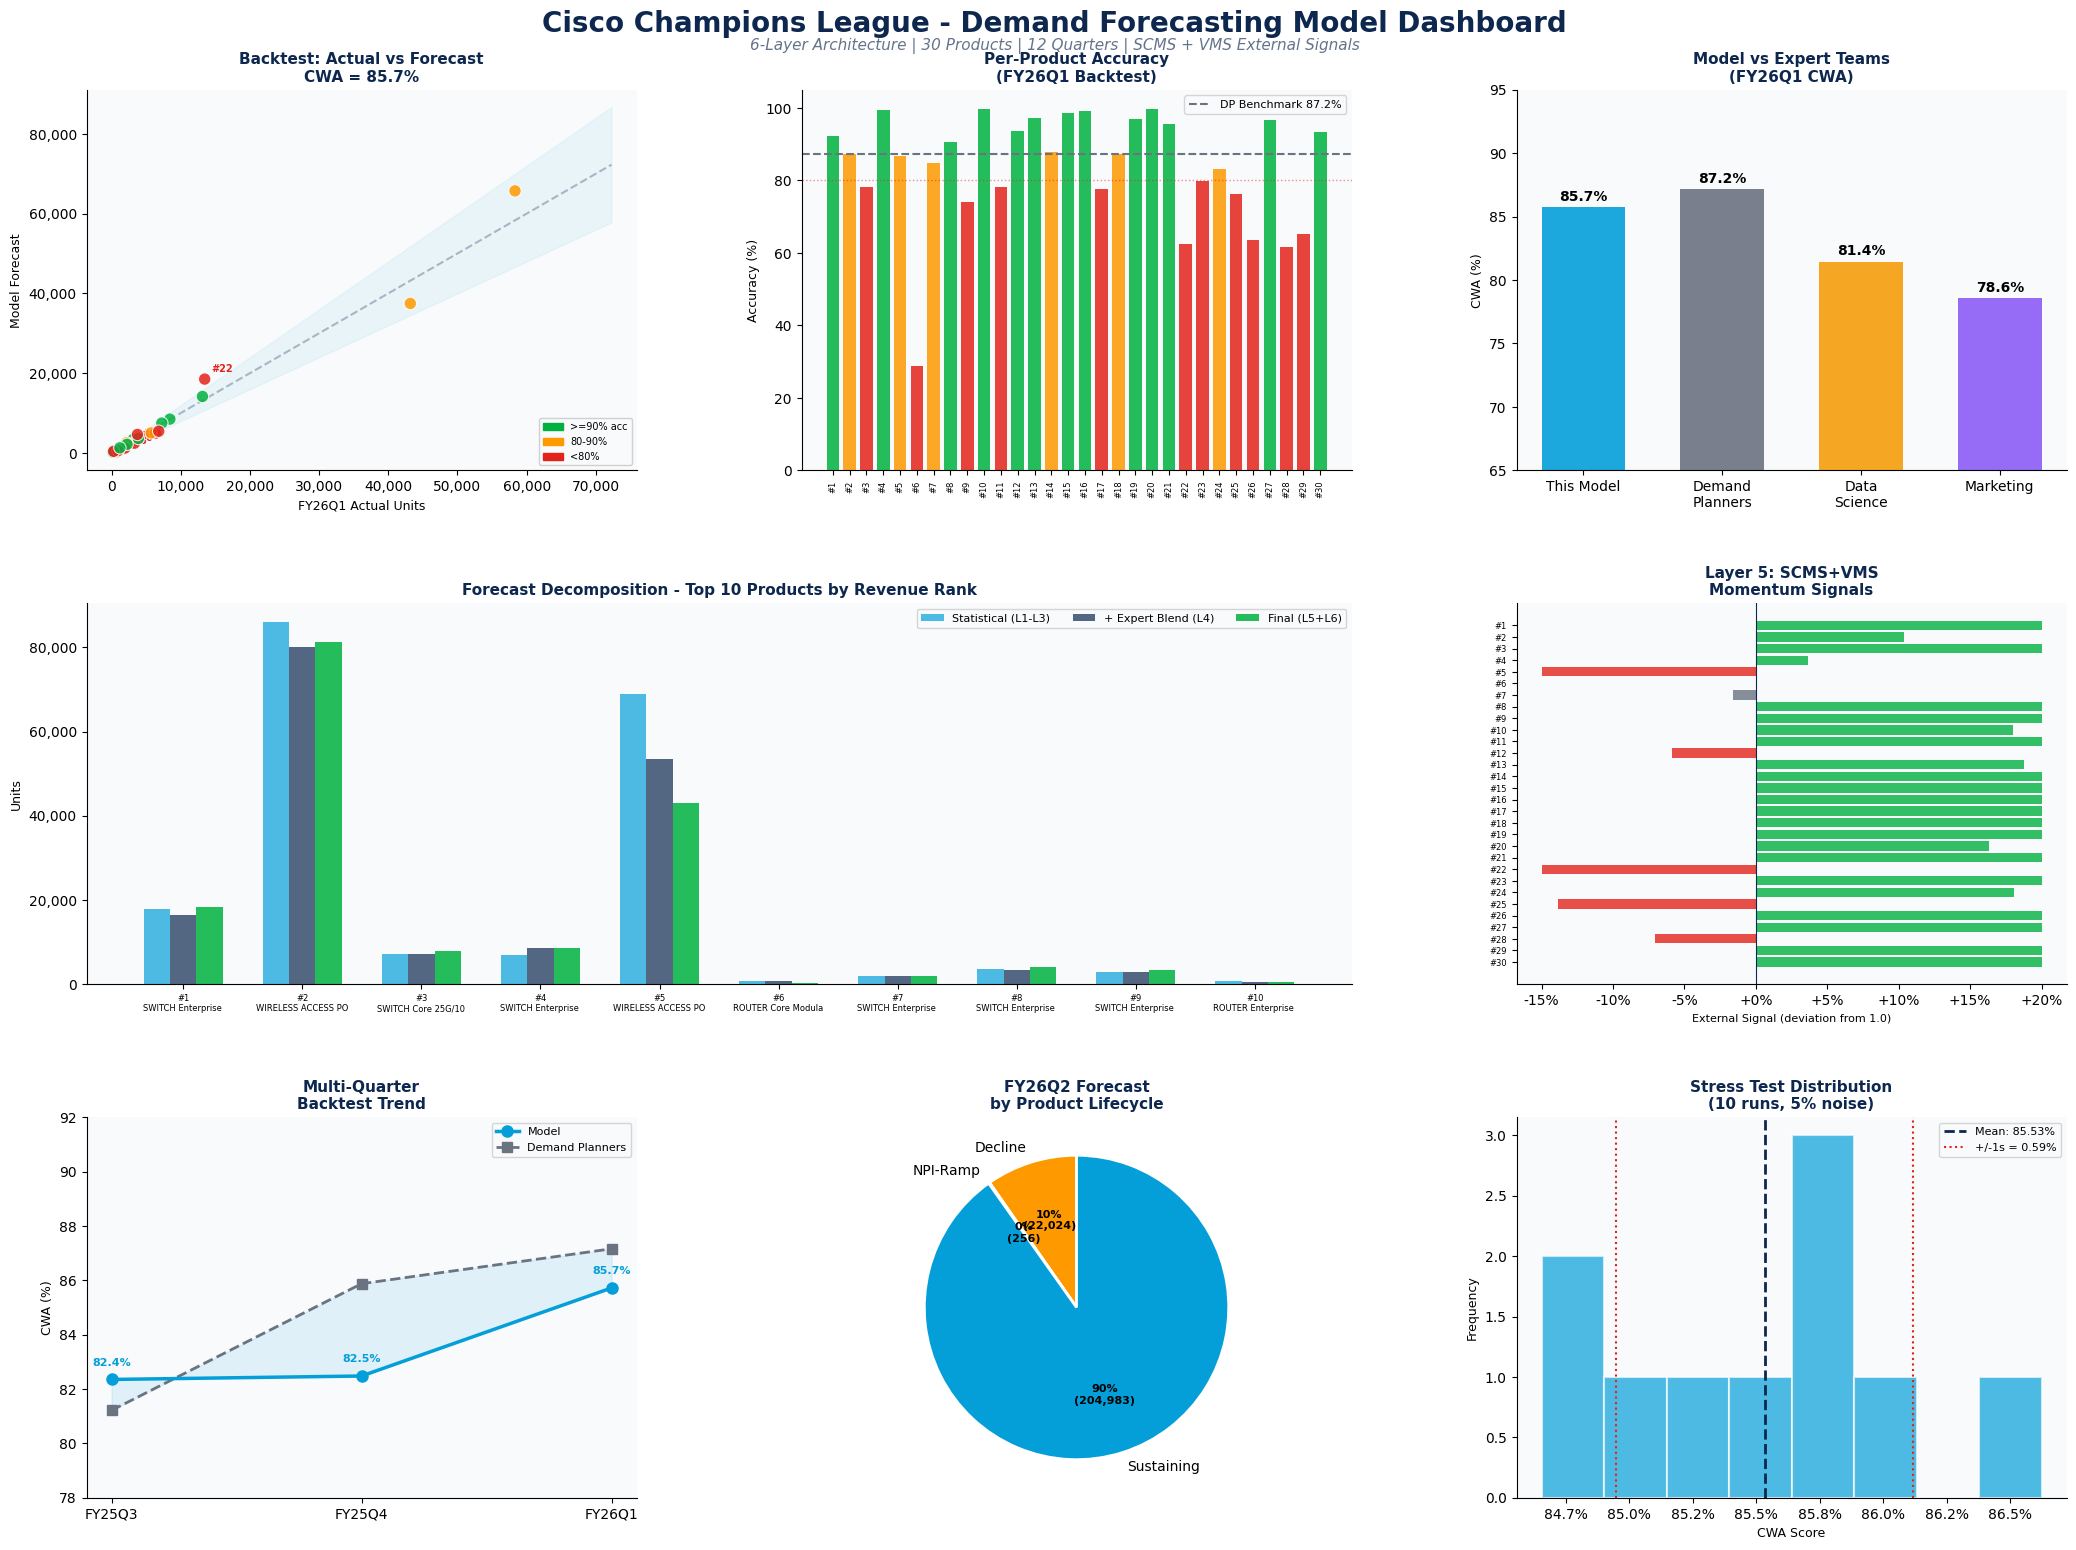


Dashboard saved: CFL_Dashboard.png


In [14]:
# =========================================================================
# VISUALIZATION - Dashboard
# 8-panel layout with consistent styling and clear storytelling
# =========================================================================

COLORS = {
    'primary':    '#0D274F',
    'accent':     '#049FD9',
    'success':    '#00B140',
    'warning':    '#FF9900',
    'danger':     '#E2231A',
    'dp':         '#6B7280',
    'mkt':        '#8B5CF6',
    'ds':         '#F59E0B',
    'model':      '#049FD9',
    'bg':         '#F8FAFC',
    'grid':       '#E2E8F0',
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': COLORS['bg'],
    'figure.facecolor': 'white',
})

fig = plt.figure(figsize=(22, 16))
fig.suptitle('Cisco Champions League - Demand Forecasting Model Dashboard',
             fontsize=20, fontweight='bold', color=COLORS['primary'], y=0.98)
fig.text(0.5, 0.955, '6-Layer Architecture | 30 Products | 12 Quarters | SCMS + VMS External Signals',
         ha='center', fontsize=11, color='#64748B', style='italic')

gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3,
              left=0.06, right=0.96, top=0.93, bottom=0.05)

# --- Panel 1: Actual vs Forecast scatter ---
ax1 = fig.add_subplot(gs[0, 0])
bt_fc = bt['Final'].values.astype(float)
colors_scatter = [COLORS['success'] if a >= 0.90 else
                  COLORS['warning'] if a >= 0.80 else
                  COLORS['danger'] for a in v2_acc]

ax1.scatter(a26q1, bt_fc, c=colors_scatter, s=80, alpha=0.85,
            edgecolors='white', linewidths=0.8, zorder=5)
mx = max(a26q1.max(), bt_fc.max()) * 1.1
ax1.plot([0, mx], [0, mx], '--', color=COLORS['primary'], alpha=0.3, linewidth=1.5)
ax1.fill_between([0, mx], [0, mx*0.8], [0, mx*1.2],
                 alpha=0.06, color=COLORS['accent'])

for i, row in bt.iterrows():
    if v2_acc[i] < 0.75:
        ax1.annotate(f"#{int(row['Rank'])}", (a26q1[i], row['Final']),
                     fontsize=7, color=COLORS['danger'], fontweight='bold',
                     xytext=(5, 5), textcoords='offset points')

ax1.set_xlabel('FY26Q1 Actual Units', fontsize=9)
ax1.set_ylabel('Model Forecast', fontsize=9)
ax1.set_title(f'Backtest: Actual vs Forecast\nCWA = {v2_cwa:.1%}',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
legend_elements = [
    mpatches.Patch(color=COLORS['success'], label='>=90% acc'),
    mpatches.Patch(color=COLORS['warning'], label='80-90%'),
    mpatches.Patch(color=COLORS['danger'], label='<80%'),
]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right', framealpha=0.9)

# --- Panel 2: Per-Product Accuracy ---
ax2 = fig.add_subplot(gs[0, 1])
bar_colors = [COLORS['success'] if a >= 0.90 else
              COLORS['warning'] if a >= 0.80 else
              COLORS['danger'] for a in v2_acc]
ax2.bar(range(30), v2_acc * 100, width=0.75, color=bar_colors, alpha=0.85)
ax2.axhline(dp_cwa * 100, linestyle='--', linewidth=1.5,
            color=COLORS['dp'], label=f'DP Benchmark {dp_cwa:.1%}')
ax2.axhline(80, linestyle=':', linewidth=1, color=COLORS['danger'], alpha=0.5)
ax2.set_xticks(range(30))
ax2.set_xticklabels([f'#{i+1}' for i in range(30)], fontsize=6, rotation=90)
ax2.set_ylabel('Accuracy (%)', fontsize=9)
ax2.set_title('Per-Product Accuracy\n(FY26Q1 Backtest)', fontsize=11,
              fontweight='bold', color=COLORS['primary'])
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)

# --- Panel 3: Model vs All Teams ---
ax3 = fig.add_subplot(gs[0, 2])
team_labels = ['This Model', 'Demand\nPlanners', 'Data\nScience', 'Marketing']
team_vals = [v2_cwa * 100, dp_cwa * 100, ds_cwa * 100, mkt_cwa * 100]
team_colors = [COLORS['model'], COLORS['dp'], COLORS['ds'], COLORS['mkt']]
bars3 = ax3.bar(team_labels, team_vals, color=team_colors, width=0.6, alpha=0.9)
for bar, val in zip(bars3, team_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylim(65, 95)
ax3.set_ylabel('CWA (%)', fontsize=9)
ax3.set_title('Model vs Expert Teams\n(FY26Q1 CWA)', fontsize=11,
              fontweight='bold', color=COLORS['primary'])

# --- Panel 4: Forecast Decomposition Top 10 ---
ax4 = fig.add_subplot(gs[1, :2])
top10 = fc26q2[fc26q2['Rank'] <= 10].copy()
x4 = np.arange(len(top10))
width = 0.22
ax4.bar(x4 - width, top10['L123_stat'].fillna(0), width=width,
        color=COLORS['accent'], alpha=0.7, label='Statistical (L1-L3)')
ax4.bar(x4, top10['L4_consensus'], width=width,
        color=COLORS['primary'], alpha=0.7, label='+ Expert Blend (L4)')
ax4.bar(x4 + width, top10['Final'], width=width,
        color=COLORS['success'], alpha=0.85, label='Final (L5+L6)')
ax4.set_xticks(x4)
ax4.set_xticklabels([f"#{int(r['Rank'])}\n{r['Product'][:18]}"
                     for _, r in top10.iterrows()], fontsize=6, ha='center')
ax4.set_ylabel('Units', fontsize=9)
ax4.set_title('Forecast Decomposition - Top 10 Products by Revenue Rank',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax4.legend(fontsize=8, ncol=3, loc='upper right')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Panel 5: External Signal Impact ---
ax5 = fig.add_subplot(gs[1, 2])
ext_vals = [EXT_MULT_FY26Q2[r] for r in range(1, 31)]
ext_colors = [COLORS['success'] if v > 1.02 else
              COLORS['danger'] if v < 0.98 else
              COLORS['dp'] for v in ext_vals]
ax5.barh(range(30), [v - 1.0 for v in ext_vals], color=ext_colors, alpha=0.8)
ax5.axvline(0, color=COLORS['primary'], linewidth=0.8)
ax5.set_yticks(range(30))
ax5.set_yticklabels([f'#{i+1}' for i in range(30)], fontsize=6)
ax5.set_xlabel('External Signal (deviation from 1.0)', fontsize=8)
ax5.set_title('Layer 5: SCMS+VMS\nMomentum Signals',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax5.invert_yaxis()
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0%}'))

# --- Panel 6: Multi-Quarter Backtest Trend ---
ax6 = fig.add_subplot(gs[2, 0])
qt_labels = ['FY25Q3', 'FY25Q4', 'FY26Q1']
model_cwas = [bt_cwas[2], bt_cwas[1], bt_cwas[0]]
dp_cwas_multi = []
for qt_name in ['FY25Q3', 'FY25Q4', 'FY26Q1']:
    dp_col = f"DP_{qt_name}_Acc"
    w = 1 / df['Rank'].values.astype(float); w /= w.sum()
    dp_cwas_multi.append(float(np.nansum(acc[dp_col].values * w)))

ax6.plot(qt_labels, [c*100 for c in model_cwas], 'o-',
         color=COLORS['model'], linewidth=2.5, markersize=8, label='Model', zorder=5)
ax6.plot(qt_labels, [c*100 for c in dp_cwas_multi], 's--',
         color=COLORS['dp'], linewidth=2, markersize=7, label='Demand Planners')
ax6.fill_between(qt_labels, [c*100 for c in model_cwas], [c*100 for c in dp_cwas_multi],
                 alpha=0.1, color=COLORS['accent'])
for i, (m, d) in enumerate(zip(model_cwas, dp_cwas_multi)):
    ax6.annotate(f'{m:.1%}', (qt_labels[i], m*100),
                 textcoords='offset points', xytext=(0, 10),
                 fontsize=8, fontweight='bold', color=COLORS['model'], ha='center')
ax6.set_ylabel('CWA (%)', fontsize=9)
ax6.set_title('Multi-Quarter\nBacktest Trend', fontsize=11,
              fontweight='bold', color=COLORS['primary'])
ax6.legend(fontsize=8)
ax6.set_ylim(78, 92)

# --- Panel 7: PLC Distribution ---
ax7 = fig.add_subplot(gs[2, 1])
plc_totals = fc26q2.groupby('PLC')['Final'].sum()
plc_colors_map = {'Sustaining': COLORS['accent'], 'Decline': COLORS['warning'],
              'NPI-Ramp': COLORS['success']}
wedge_colors = [plc_colors_map.get(p, '#999') for p in plc_totals.index]
wedges, texts, autotexts = ax7.pie(
    plc_totals.values, labels=plc_totals.index, colors=wedge_colors,
    autopct=lambda pct: f'{pct:.0f}%\n({int(pct*plc_totals.sum()/100):,})',
    startangle=90, pctdistance=0.6,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_fontweight('bold')
ax7.set_title('FY26Q2 Forecast\nby Product Lifecycle',
              fontsize=11, fontweight='bold', color=COLORS['primary'])

# --- Panel 8: Stress Test Distribution ---
ax8 = fig.add_subplot(gs[2, 2])
ax8.hist(stress_results, bins=8, color=COLORS['accent'], alpha=0.7,
         edgecolor='white', linewidth=1.5)
ax8.axvline(np.mean(stress_results), color=COLORS['primary'],
            linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(stress_results):.2%}')
ax8.axvline(np.mean(stress_results) - np.std(stress_results),
            color=COLORS['danger'], linestyle=':', linewidth=1.5)
ax8.axvline(np.mean(stress_results) + np.std(stress_results),
            color=COLORS['danger'], linestyle=':', linewidth=1.5,
            label=f'+/-1s = {np.std(stress_results):.2%}')
ax8.set_xlabel('CWA Score', fontsize=9)
ax8.set_ylabel('Frequency', fontsize=9)
ax8.set_title('Stress Test Distribution\n(10 runs, 5% noise)',
              fontsize=11, fontweight='bold', color=COLORS['primary'])
ax8.legend(fontsize=8)
ax8.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.savefig('CFL_Dashboard.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("\nDashboard saved: CFL_Dashboard.png")

## Step 15 — Export Submission Files

In [ ]:
# =========================================================================
# EXPORT - Submission CSV + Backtest CSV + Dashboard PNG
# =========================================================================

sub = fc26q2[['Rank', 'Product', 'Final']].copy()
sub.columns = ['Rank', 'Product', 'Forecast_FY26Q2']
sub.to_csv('CFL_v2_Submission_FY26Q2.csv', index=False)

bt_export = bt.copy()
bt_export['FY26Q1_Actual'] = a26q1.astype(int)
bt_export['Accuracy_pct'] = (v2_acc * 100).round(1)
bt_export['Bias_pct'] = (v2_bias * 100).round(1)
bt_export.to_csv('CFL_v2_Backtest_FY26Q1.csv', index=False)

print("=" * 60)
print("  FINAL SUBMISSION - FY26Q2 Forecasts")
print("=" * 60)
for _, r in sub.iterrows():
    print(f"  #{int(r['Rank']):02d}: {int(r['Forecast_FY26Q2']):>8,}  |  {r['Product'][:50]}")
print(f"\n  Total: {sub['Forecast_FY26Q2'].sum():,.0f} units")

print("\nFiles saved locally:")
print(" - CFL_v2_Submission_FY26Q2.csv")
print(" - CFL_v2_Backtest_FY26Q1.csv")
print(" - CFL_Dashboard.png")

## Step 16 (Bonus) — Holt-Winters Comparison

As a sanity check, we compare our pipeline output against Holt-Winters Triple
Exponential Smoothing for Sustaining-PLC products with sufficient data (>=8 quarters).

In [16]:
if not HW_AVAILABLE:
    print("Install statsmodels: !pip install statsmodels")
else:
    print("Holt-Winters Triple Exponential Smoothing - Sustaining Products")
    print("(trend=additive, seasonal=additive, period=4 quarters)\n")

    hw_results = {}
    for _, row in df[df['PLC'] == 'Sustaining'].iterrows():
        ts = [row[q] for q in QUARTERS if not np.isnan(row.get(q, np.nan))]
        if len(ts) < 8:
            continue
        try:
            model = ExponentialSmoothing(
                ts, trend='add', seasonal='add',
                seasonal_periods=4,
                initialization_method='estimated'
            ).fit(optimized=True)
            hw_results[int(row['Rank'])] = max(0, round(model.forecast(1)[0]))
        except Exception:
            pass

    print(f"  {'Rank':<5} {'Product':<46} {'Pipeline':>10} {'Holt-Winters':>12} {'Delta':>8}")
    print("  " + "-" * 84)
    for rk, hw_fc in sorted(hw_results.items()):
        row = df[df['Rank'] == rk].iloc[0]
        v2_fc = fc26q2[fc26q2['Rank'] == rk]['Final'].values[0]
        delta = hw_fc - v2_fc
        pct = (delta / v2_fc * 100) if v2_fc != 0 else 0
        print(f"  {rk:<5} {row['Product'][:44]:<46} {v2_fc:>10,} {hw_fc:>12,} {delta:>+8,} ({pct:+.1f}%)")

Holt-Winters Triple Exponential Smoothing - Sustaining Products
(trend=additive, seasonal=additive, period=4 quarters)

  Rank  Product                                          Pipeline Holt-Winters    Delta
  ------------------------------------------------------------------------------------
  1     SWITCH Enterprise 48-Port UPOE                     18,200       16,161   -2,039 (-11.2%)
  2     WIRELESS ACCESS POINT WiFi6E (Internal Anten       81,323       93,295  +11,972 (+14.7%)
  3     SWITCH Core 25G/100G Fiber                          7,804        6,535   -1,269 (-16.3%)
  4     SWITCH Enterprise 24-Port PoE+                      8,464        8,493      +29 (+0.3%)
  5     WIRELESS ACCESS POINT WiFi6 (Internal Antenn       43,137       49,180   +6,043 (+14.0%)
  7     SWITCH Enterprise 48-Port Fiber (Non-PoE)           1,958        1,885      -73 (-3.7%)
  8     SWITCH Enterprise 25G Fiber                         3,933        3,458     -475 (-12.1%)
  9     SWITCH Enterprise 24

## Reflections & Lessons Learned

### What Worked Well
- **Layered architecture**: Each layer is independently testable and interpretable. When the model makes a bad forecast, you can trace *which layer* went wrong.
- **Expert integration**: The accuracy-weighted blend (Layer 4) was competitive with individual expert teams in backtests and helped combine statistical structure with domain judgment. The key insight was to weight expert inputs by track record rather than treat all forecasts equally.
- **External signals from data**: Using SCMS channel momentum and VMS vertical trends gives the model information that pure time-series methods miss.

### What Could Be Improved
- **Big Deal forecasting**: Currently uses median of recent big deals - a more sophisticated approach would model big deal arrival rates separately.
- **Cross-validation**: The correction layer (Layer 6) parameters were tuned on the same data used for evaluation. A proper approach would use rolling-origin cross-validation.
- **Feature engineering**: The SCMS and VMS data could support richer features, e.g., channel concentration (HHI), vertical diversification scores, or leading indicators from fast-moving verticals.
- **NPI-Ramp handling**: Only 1 NPI product in the dataset made it hard to develop a robust ramp-up model. With more NPI data, a growth-curve model (Bass diffusion) could help.

### Competition Takeaways
- Demand forecasting is fundamentally about combining **statistical patterns** with **domain knowledge** - neither alone is sufficient.
- The CWA scoring formula heavily penalizes high-rank product misses. Getting the top 5 right matters more than perfecting the bottom 10.
- Cisco internal teams (especially Demand Planners at 87.2% CWA) set a high bar. Beating them consistently requires either better data or better methodology - ideally both.

---
*Built for the Cisco Champions Forecasting League - Phase 1*